# Prediction

With the neural network trained, this notebook predict the evolution of the plasma state over time. 

In [1]:
import os
import sys
import glob
import h5py
import torch as t
import numpy as np
from torch import nn
import multiprocessing
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from timm.models.layers import trunc_normal_

/tmp/chenxingzhuo/StaDiff/lib/python3.12/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


# Load the Network

The network is stored in the directory defined in "modelSaveDir". Moreover, the neural network related functions are also defined as during the training. Sometimes the numerical stability issue could be observed after multiple iterations of time marching, we therefore enforce the neural network to be in double precision, although the neural network is trained with single precision. 

In [3]:
modelSaveDir='OperatorSaverPIC3XFL/lr0.0003/'

In [4]:
timeGrid=0.005
gridNum=128
batchSmallSize=30#24
predLongTime=1
predLongStep=int(predLongTime/timeGrid)
muVal=5e-10

uD2k=t.meshgrid(*[t.fft.fftfreq(int(n)) for n in (gridNum,gridNum)],indexing="ij")
uD2k=t.stack(uD2k,-1)
uD2k=t.sum(uD2k**2,axis=-1).cuda()
fft_laplace=-((2*np.pi)**2)*uD2k
fft_laplace[0,0]=np.inf

In [5]:
def unwrapDelta2(tensor,dx):
    frequencies=t.fft.fft2(tensor)
    result=frequencies/(fft_laplace)
    result=t.where(fft_laplace==0,0,result)
    result=t.real(t.fft.ifft2(result))
    return result*dx**2
def periodicLaplace(fieldIn,dx):
    fieldPad=nn.functional.pad(fieldIn,(1,1,1,1),'circular')
    fieldOut=fieldPad[:,0:-2,1:-1]+fieldPad[:,1:-1,0:-2]-4*fieldPad[:,1:-1,1:-1]+fieldPad[:,1:-1,2:]+fieldPad[:,2:,1:-1]
    return fieldOut/dx**2
def arakawaVec(zeta,psi,dx):
    return (zeta[:,1:-1,2:  ]*(psi[:,2:  ,1:-1]-psi[:,0:-2,1:-1]+psi[:,2:  ,2:  ]-psi[:,0:-2,2:  ])
           -zeta[:,1:-1,0:-2]*(psi[:,2:  ,1:-1]-psi[:,0:-2,1:-1]+psi[:,2:  ,0:-2]-psi[:,0:-2,0:-2])
           -zeta[:,2:  ,1:-1]*(psi[:,1:-1,2:  ]-psi[:,1:-1,0:-2]+psi[:,2:  ,2:  ]-psi[:,2:  ,0:-2])
           +zeta[:,0:-2,1:-1]*(psi[:,1:-1,2:  ]-psi[:,1:-1,0:-2]+psi[:,0:-2,2:  ]-psi[:,0:-2,0:-2])
           +zeta[:,0:-2,2:  ]*(psi[:,1:-1,2:  ]-psi[:,0:-2,1:-1])
           +zeta[:,2:  ,2:  ]*(psi[:,2:  ,1:-1]-psi[:,1:-1,2:  ])
           -zeta[:,2:  ,0:-2]*(psi[:,2:  ,1:-1]-psi[:,1:-1,0:-2])
           -zeta[:,0:-2,0:-2]*(psi[:,1:-1,0:-2]-psi[:,0:-2,1:-1]))/(12*dx**2)
def hwCalTD(omegaDenIn,c1,kappa,pbc,spaGrid):
    phi1=unwrapDelta2(omegaDenIn[:,0],spaGrid)

    phiPad=nn.functional.pad(phi1,(1,1,1,1),'circular')
    denPad=nn.functional.pad(omegaDenIn[:,1],(1,1,1,1),'circular')
    phi1X=(phiPad[:,2:,1:-1]-phiPad[:,0:-2,1:-1])/(2*spaGrid)
    phi1Y=(phiPad[:,1:-1,2:]-phiPad[:,1:-1,0:-2])/(2*spaGrid)
    den1X=(denPad[:,2:,1:-1]-denPad[:,0:-2,1:-1])/(2*spaGrid)
    den1Y=(denPad[:,1:-1,2:]-denPad[:,1:-1,0:-2])/(2*spaGrid)
    omegaPad=nn.functional.pad(omegaDenIn[:,0],(1,1,1,1),'circular')
    omega1X=(omegaPad[:,2:,1:-1]-omegaPad[:,0:-2,1:-1])/(2*spaGrid)
    omega1Y=(omegaPad[:,1:-1,2:]-omegaPad[:,1:-1,0:-2])/(2*spaGrid)
    diffuTermDen=periodicLaplace(periodicLaplace(periodicLaplace(omegaDenIn[:,1],spaGrid),spaGrid),spaGrid)
    diffuTermOmg=periodicLaplace(periodicLaplace(periodicLaplace(omegaDenIn[:,0],spaGrid),spaGrid),spaGrid)
    denT1=c1.view([-1,1,1])*(phi1-omegaDenIn[:,1])-pbc.view([-1,1,1])*arakawaVec(phiPad,denPad,spaGrid)-kappa.view([-1,1,1])*phi1X+muVal*diffuTermDen
    omegaT1=c1.view([-1,1,1])*(phi1-omegaDenIn[:,1])-pbc.view([-1,1,1])*arakawaVec(phiPad,omegaPad,spaGrid)+muVal*diffuTermOmg
    
    omegaDenT=t.stack([omegaT1,denT1],axis=1)
    return omegaDenT

def rk4DiffCal(omegaDenIn,c1,kappa,pbc,spaGrid,tGrid):
    omegaDenT1=hwCalTD(omegaDenIn,c1,kappa,pbc,spaGrid)
    omegaDenIn2=omegaDenIn+omegaDenT1*tGrid.view([-1,1,1,1])/2
    omegaDenT2=hwCalTD(omegaDenIn2,c1,kappa,pbc,spaGrid)
    omegaDenIn3=omegaDenIn+omegaDenT2*tGrid.view([-1,1,1,1])/2
    omegaDenT3=hwCalTD(omegaDenIn3,c1,kappa,pbc,spaGrid)
    omegaDenIn4=omegaDenIn+omegaDenT3*tGrid.view([-1,1,1,1])
    omegaDenT4=hwCalTD(omegaDenIn4,c1,kappa,pbc,spaGrid)
    omegaDenDiff=(omegaDenT1+2*omegaDenT2+2*omegaDenT3+omegaDenT4)*tGrid.view([-1,1,1,1])/6
    return omegaDenDiff

class LayerNorm(nn.Module):
    """ LayerNorm that supports two data formats: channels_last (default) or channels_first. 
    The ordering of the dimensions in the inputs. channels_last corresponds to inputs with 
    shape (batch_size, height, width, channels) while channels_first corresponds to inputs 
    with shape (batch_size, channels, height, width).
    """
    def __init__(self,normalized_shape,eps=1e-6,data_format="channels_last"):
        super().__init__()
        self.weight=nn.Parameter(t.ones(normalized_shape))
        self.bias=nn.Parameter(t.zeros(normalized_shape))
        self.eps=eps
        self.data_format=data_format
        if self.data_format not in ["channels_last","channels_first"]:
            raise NotImplementedError 
        self.normalized_shape=(normalized_shape,)
    def forward(self,x):
        if self.data_format=="channels_last":
            return t.nn.functional.layer_norm(x,self.normalized_shape,self.weight,self.bias,self.eps)
        elif self.data_format == "channels_first":
            u=x.mean(1,keepdim=True)
            s=(x-u).pow(2).mean(1,keepdim=True)
            x=(x-u)/t.sqrt(s+self.eps)
            x=self.weight[:,None,None]*x+self.bias[:,None,None]
            return x

class GRN(nn.Module): #GRN (Global Response Normalization) layer
    def __init__(self,dim):
        super().__init__()
        self.gamma=nn.Parameter(t.zeros(1,1,1,dim))
        self.beta=nn.Parameter(t.zeros(1,1,1,dim))
    def forward(self,x):
        Gx=t.norm(x,p=2,dim=(1,2),keepdim=True)
        Nx=Gx/(Gx.mean(dim=-1,keepdim=True)+1e-6)
        return self.gamma*(x*Nx)+self.beta+x

class Block(nn.Module):
    """ ConvNeXtV2 Block.
    Args:
        dim (int): Number of input channels.
        drop_path (float): Stochastic depth rate. Default: 0.0
    """
    def __init__(self,dim,drop_path=0.0):
        super().__init__()
        self.dwconv=nn.Conv2d(dim,dim,kernel_size=7,padding=3,groups=dim,padding_mode='circular') # depthwise conv
        self.norm=LayerNorm(dim, eps=1e-6)
        self.pwconv1=nn.Linear(dim,4*dim) # pointwise/1x1 convs, implemented with linear layers
        self.act=nn.GELU()
        self.grn=GRN(4*dim)
        self.pwconv2=nn.Linear(4*dim,dim)
        self.drop_path=DropPath(drop_path) if drop_path>0.0 else nn.Identity()
    def forward(self,x):
        input=x
        x=self.dwconv(x)
        x=x.permute(0,2,3,1)# (N, C, H, W) -> (N, H, W, C)
        x=self.norm(x)
        x=self.pwconv1(x)
        x=self.act(x)
        x=self.grn(x)
        x=self.pwconv2(x)
        x=x.permute(0,3,1,2)# (N, H, W, C) -> (N, C, H, W)
        x=input+self.drop_path(x)
        return x

class ConvNeXtV2(nn.Module):
    """ ConvNeXt V2
    Args:
        in_chans (int): Number of input image channels. Default: 3
        num_classes (int): Number of classes for classification head. Default: 1000
        depths (tuple(int)): Number of blocks at each stage. Default: [3, 3, 9, 3]
        dims (int): Feature dimension at each stage. Default: [96, 192, 384, 768]
        drop_path_rate (float): Stochastic depth rate. Default: 0.
        head_init_scale (float): Init scaling value for classifier weights and biases. Default: 1.
    """
    def __init__(self,in_chans=8,out_channel=2,depths=[3,3,9,3],dims=[96,192,384,768],drop_path_rate=0.0,head_init_scale=1.0):
        super().__init__()
        self.depths=depths
        self.num_stage=len(depths)
        self.downsample_layers=nn.ModuleList() # stem and 3 intermediate downsampling conv layers
        stem = nn.Sequential(nn.Conv2d(in_chans,dims[0],kernel_size=2,stride=2),
                             LayerNorm(dims[0],eps=1e-6,data_format="channels_first"))
        self.downsample_layers.append(stem)
        for i in range(self.num_stage-1):
            downsample_layer=nn.Sequential(LayerNorm(dims[i],eps=1e-6,data_format="channels_first"),
                                           nn.Conv2d(dims[i],dims[i+1],kernel_size=2,stride=2))
            self.downsample_layers.append(downsample_layer)
        self.stages=nn.ModuleList() # 4 feature resolution stages, each consisting of multiple residual blocks
        dp_rates=[x.item() for x in t.linspace(0,drop_path_rate,sum(depths))] 
        cur=0
        for i in range(self.num_stage):
            stage=nn.Sequential(*[Block(dim=dims[i],drop_path=dp_rates[cur+j]) for j in range(depths[i])])
            self.stages.append(stage)
            cur+=depths[i]
        self.norm=nn.LayerNorm(dims[-1],eps=1e-6)# final norm layer
        self.out_conv=nn.Conv2d(int(dims[0]/2),out_channel,kernel_size=1) # final classifier conv
        self.upsample_layers=nn.ModuleList() # stem and 3 intermediate downsampling conv layers
        for i in reversed(range(self.num_stage)):
            upsample_layer = nn.Sequential(LayerNorm(dims[i]*2,eps=1e-6,data_format="channels_first"),
                                           nn.ConvTranspose2d(dims[i]*2,int(dims[i]/2),kernel_size=2,stride=2))
            self.upsample_layers.append(upsample_layer)
        self.apply(self._init_weights)
    def _init_weights(self,m):
        if isinstance(m,(nn.Conv2d,nn.Linear)):
            trunc_normal_(m.weight,std=0.02)
            nn.init.constant_(m.bias,0)
    def Encoder(self,x):
        down_features=[]
        for i in range(self.num_stage):
            x=self.downsample_layers[i](x)
            x=self.stages[i](x)
            down_features.append(x)
        return x,down_features
    def Decoder(self,x,down_features):
        for i in range(self.num_stage):
            x=t.cat([x,down_features.pop()],dim=1)
            x=self.upsample_layers[i](x)
        return x
    def forward(self,x):
        x,down_features=self.Encoder(x)
        x=self.Decoder(x, down_features)
        #x=self.norm(x)#Gesa: The copy code forgot to use this norm layer, and the norm layer seems in wrong shape
        x=self.out_conv(x)
        return x
PICNXnet=ConvNeXtV2().double().cuda()
PICNXnet=t.load(modelSaveDir+'PICNX.pt',weights_only=False).double().eval()

In [6]:
chanRescale=t.tensor([100,20]).reshape([1,2,1,1]).double().cuda()

# Testing Data

We pick a numerical simulation instance in the testing data set to test the neural network training performance.  

In [7]:
sfNameOne='FiveHWRunner/storeField_3_12.h5'

with h5py.File(sfNameOne) as h5File:
    dens=np.array(h5File['density'])
    omega=np.array(h5File['omega'])
    phi=np.array(h5File['phi'])
    enstrophy=np.array(h5File['enstrophy'])
    enstrophyPhi=np.array(h5File['enstrophy_phi'])
    gammac=np.array(h5File['gamma_c'])
    gamman=np.array(h5File['gamma_n'])
    gammaNSp=np.array(h5File['gamma_n_spectral'])
    kineEng=np.array(h5File['kinetic_energy'])
    therEng=np.array(h5File['thermal_energy'])
quantiList=np.array([enstrophy,enstrophyPhi,gammac,gamman,gammaNSp,kineEng,therEng]).T

ind1=int(sfNameOne.split('/')[-1].split('.h5')[0].split('_')[1])
ind2=int(sfNameOne.split('/')[-1].split('.h5')[0].split('_')[2])
c1=np.load('FiveHWRunner/c1List_'+str(ind1)+'.npy')[ind2]
k0=np.load('FiveHWRunner/k0List_'+str(ind1)+'.npy')[ind2]
kappa=np.load('FiveHWRunner/kappaList_'+str(ind1)+'.npy')[ind2]
pbc=np.load('FiveHWRunner/pbcList_'+str(ind1)+'.npy')[ind2]

timeList=np.arange(len(dens))*timeGrid
mask=(dens.max(axis=(1,2))>2)&(dens.max(axis=(1,2))<20)
dens=dens[mask]
phi=phi[mask]
omega=omega[mask]
timeList=timeList[mask]
quantiList=quantiList[mask]

c1=t.tensor([[c1]]).double().cuda()
k0=t.tensor([[k0]]).double().cuda()

kappa=t.tensor([[kappa]]).double().cuda()
pbc=t.tensor([[pbc]]).double().cuda()

print(len(dens),mask.shape)

LBox=2*np.pi/k0
spaGrid=(LBox/gridNum).reshape([-1,1,1])

20993 (40001,)


# The Physical Parameters

We use the PICON to predict the plasma state up to t=200, which is about 90-fold of time marching, then calculate the physical quantaties $\Gamma_n$ and $\Gamma_c$ over the predicted plasma state time sequences, finally make comparison to the numerical simulation result.  

In [8]:
tStartIndex=1200
omegaPhiDenIn=t.hstack([t.tensor(omega[[tStartIndex]][None]),
                        t.tensor(phi[[tStartIndex]][None]),
                        t.tensor(dens[[tStartIndex]][None])]).double().cuda()
gammacPredList=[]
gammacTrueList=[]
gammanPredList=[]
gammanTrueList=[]
for i in range(90):
    for j in range(1,11):
        tLargeStep=20*j
        timeOne=tLargeStep*timeGrid
        tDiffSeq=t.tensor([[timeOne]]).double().cuda()
        with t.no_grad():
            OPDTCKKP=t.cat([omegaPhiDenIn,
                            tDiffSeq.reshape([-1,1,1,1])*t.ones([1,1,128,128]).cuda(),
                            c1*t.ones([1,1,128,128]).cuda(),
                            k0*t.ones([1,1,128,128]).cuda(),
                            kappa*t.ones([1,1,128,128]).cuda(),
                            pbc*t.ones([1,1,128,128]).cuda()
                           ],axis=1)
            Encoded,midStage=PICNXnet.Encoder(OPDTCKKP)
            omegaDenPred=PICNXnet.out_conv(PICNXnet.Decoder(Encoded,midStage))*tDiffSeq.reshape([-1,1,1,1])*chanRescale+omegaPhiDenIn[:,[0,2]]
        phiPred=unwrapDelta2(omegaDenPred[:,0],spaGrid)
        phiPad=nn.functional.pad(phiPred,(1,1,1,1),'circular')
        phiX=(phiPad[:,2:,1:-1]-phiPad[:,0:-2,1:-1])/(2*spaGrid)
        gammacPredList.append(t.mean((omegaDenPred[0,1]-phiPred[0])**2).item()*c1.item())
        gammacTrueList.append(quantiList[tStartIndex+i*200+tLargeStep,2])
        gammanPredList.append(-t.mean(omegaDenPred[0,1]*phiX).item())
        gammanTrueList.append(quantiList[tStartIndex+i*200+tLargeStep,3])
    omegaPhiDenIn[0,0]=omegaDenPred[0,0].clone().detach()
    omegaPhiDenIn[0,1]=phiPred[0].clone().detach()
    omegaPhiDenIn[0,2]=omegaDenPred[0,1].clone().detach()
    


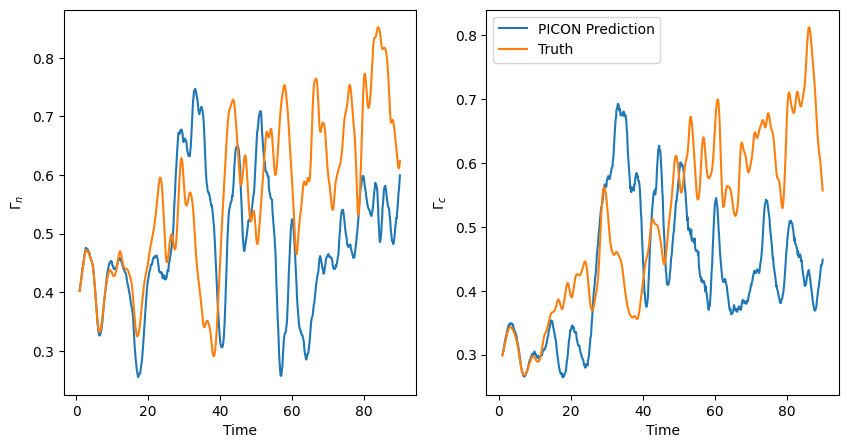

In [9]:
plt.subplot(1,2,1)
plt.plot(np.linspace(1,1*90,num=900),gammanPredList,label='PICON Prediction')
plt.plot(np.linspace(1,1*90,num=900),gammanTrueList,label='Truth')
#plt.legend()
plt.xlabel('Time')
plt.ylabel(r'$\Gamma_n$')

plt.subplot(1,2,2)
plt.plot(np.linspace(1,1*90,num=900),gammacPredList,label='PICON Prediction')
plt.plot(np.linspace(1,1*90,num=900),gammacTrueList,label='Truth')
plt.legend()
plt.xlabel('Time')
plt.ylabel(r'$\Gamma_c$')
plt.gcf().set_size_inches(10,5)
#plt.savefig('plotout/PaperPlot/physQuan.png')

# One Step Prediction

The plasma state is predicted for one step using PICON, at t=0.8 after the input plasma state. Note that the PICON predicted $\phi$ value is calculated from the $\Omega$ value using the spectral method. We also show the difference images and calculate the MSE between the prediction and the numerical simulation results. 

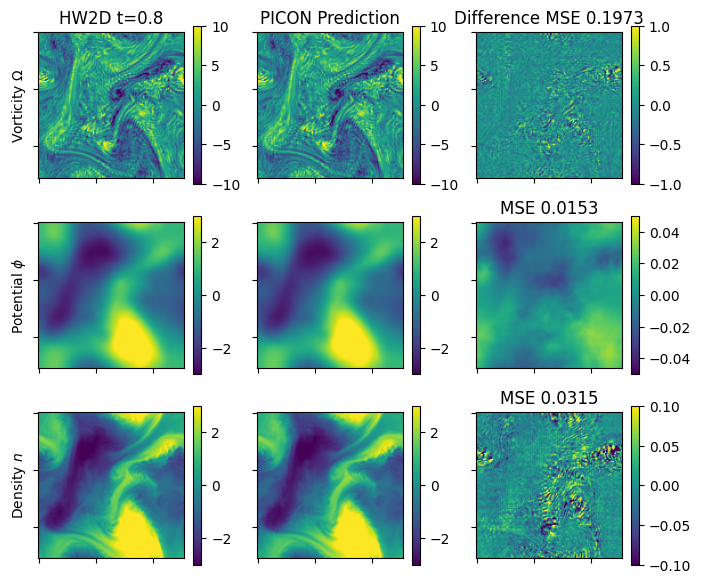

In [10]:
tStartIndex=5000

omegaPhiDenIn=t.hstack([t.tensor(omega[[tStartIndex]][None]),
                        t.tensor(phi[[tStartIndex]][None]),
                        t.tensor(dens[[tStartIndex]][None])]).double().cuda()
for i in range(1):
    timeOne=0.8
    tDiffSeq=t.tensor([[timeOne]]).double().cuda()
    with t.no_grad():
        OPDTCKKP=t.cat([omegaPhiDenIn,
                        tDiffSeq.reshape([-1,1,1,1])*t.ones([1,1,128,128]).cuda(),
                        c1*t.ones([1,1,128,128]).cuda(),
                        k0*t.ones([1,1,128,128]).cuda(),
                        kappa*t.ones([1,1,128,128]).cuda(),
                        pbc*t.ones([1,1,128,128]).cuda()
                       ],axis=1)
        Encoded,midStage=PICNXnet.Encoder(OPDTCKKP)
        omegaDenPred=PICNXnet.out_conv(PICNXnet.Decoder(Encoded,midStage))*tDiffSeq.reshape([-1,1,1,1])*chanRescale+omegaPhiDenIn[:,[0,2]]
    phiPred=unwrapDelta2(omegaDenPred[:,0],spaGrid)
    omegaPhiDenIn[0,0]=omegaDenPred[0,0].clone().detach()
    omegaPhiDenIn[0,1]=phiPred[0].clone().detach()
    omegaPhiDenIn[0,2]=omegaDenPred[0,1].clone().detach()
timeLong=160

plt.subplot(3,3,1)
clb=plt.imshow(omega[tStartIndex+timeLong],vmin=-10,vmax=10)
plt.colorbar(clb)
plt.xticks(visible=False)
plt.yticks(visible=False)
plt.title(r'HW2D t='+str(timeOne))
plt.ylabel(r'Vorticity $\Omega$')
plt.subplot(3,3,2)
clb=plt.imshow(omegaDenPred[0,0].cpu().numpy(),vmin=-10,vmax=10)
plt.colorbar(clb)
plt.xticks(visible=False)
plt.yticks(visible=False)
plt.title('PICON Prediction')
plt.subplot(3,3,3)
clb=plt.imshow(omega[tStartIndex+timeLong]-omegaDenPred[0,0].cpu().numpy(),vmin=-1,vmax=1)
plt.colorbar(clb)
plt.xticks(visible=False)
plt.yticks(visible=False)
mseValue=np.mean((omega[tStartIndex+timeLong]-omegaDenPred[0,0].cpu().numpy())**2)**0.5
plt.title('Difference MSE '+str(round(mseValue,4)))

plt.subplot(3,3,4)
clb=plt.imshow(phi[tStartIndex+timeLong],vmin=-3,vmax=3)
plt.xticks(visible=False)
plt.yticks(visible=False)
plt.ylabel(r'Potential $\phi$')
plt.colorbar(clb)
plt.subplot(3,3,5)
clb=plt.imshow(phiPred[0].cpu().numpy(),vmin=-3,vmax=3)
plt.xticks(visible=False)
plt.yticks(visible=False)
plt.colorbar(clb)
plt.subplot(3,3,6)
clb=plt.imshow(phi[tStartIndex+timeLong]-phiPred[0].cpu().numpy(),vmin=-0.05,vmax=0.05)
plt.colorbar(clb)
plt.xticks(visible=False)
plt.yticks(visible=False)
mseValue=np.mean((phi[tStartIndex+timeLong]-phiPred[0].cpu().numpy())**2)**0.5
plt.title('MSE '+str(round(mseValue,4)))

plt.subplot(3,3,7)
clb=plt.imshow(dens[tStartIndex+timeLong],vmin=-3,vmax=3)
plt.xticks(visible=False)
plt.yticks(visible=False)
plt.colorbar(clb)
plt.ylabel(r'Density $n$')
plt.subplot(3,3,8)
clb=plt.imshow(omegaDenPred[0,1].cpu().numpy(),vmin=-3,vmax=3)
plt.xticks(visible=False)
plt.yticks(visible=False)
plt.colorbar(clb)
plt.subplot(3,3,9)
clb=plt.imshow(dens[tStartIndex+timeLong]-omegaDenPred[0,1].cpu().numpy(),vmin=-0.1,vmax=0.1)
plt.colorbar(clb)
plt.xticks(visible=False)
plt.yticks(visible=False)
mseValue=np.mean((dens[tStartIndex+timeLong]-omegaDenPred[0,1].cpu().numpy())**2)**0.5
plt.title('MSE '+str(round(mseValue,4)))
plt.gcf().set_size_inches(8,7)
#plt.savefig('plotout/PaperPlot/OneSnap.png')